# 1. Problem Statement

## Loan Approval Prediction using Decision Tree

The objective of this project is to build a **Supervised Machine Learning
classification model using a Decision Tree Classifier** to predict whether
a loan application will be approved or rejected.

The model will learn from historical loan application data and classify
new applications into two categories:

- **Y (Yes)** → Loan Approved
- **N (No)** → Loan Rejected

# 2. Dataset

For this project, we are using a Loan Approval Dataset containing information
about applicants and their financial details.

The dataset contains **4,269 loan applications** and **13 columns**.

The target variable is **loan_status**, which contains two classes:

- **Approved** → Loan application is approved
- **Rejected** → Loan application is rejected

In [100]:
# import pandas
import pandas as pd
import numpy as np

# upload dataset
df=pd.read_csv("/content/loan_approval_dataset.csv")   #read_csv() is used to read the CSV file.


df.head()





,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [101]:
df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


#3. Data Cleaning & Preprocessing

Duplicate rows,
Missing values,
Column names mein extra spaces,
Categorical values,
loan_id ko remove karna,
Target variable ko numeric form mein convert karna.

In [102]:
#3.1check duplicate values

df.duplicated().sum()   # duplicated() checks whether the dataset contains
                        # any completely repeated rows.





np.int64(0)

In [103]:

#3.2 check missing values
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [104]:
# 3.3check columns names
df.columns = df.columns.str.strip() # strip() removes unnecessary spaces from the beginning and end of every column name
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [105]:
#3.4 Check Categorical Values



print("Education:")
print(df['education'].value_counts())

print("\nSelf Employed:")
print(df['self_employed'].value_counts())

print("\nLoan Status:")
print(df['loan_status'].value_counts())

Education:
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Self Employed:
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

Loan Status:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [106]:
#3.5 remove loan id

# loan_id is only an identification number.
# It does not represent a meaningful characteristic of the applicant.
df = df.drop('loan_id', axis=1)

# Display the remaining columns to confirm that loan_id is removed.
df.columns


Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [107]:
# Remove extra spaces from column names.
df.columns = df.columns.str.strip()

# Remove extra spaces from text values.
# This is different from cleaning column names.
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

# Convert education into numerical values.
df['education'] = df['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

# Convert self-employment status into numerical values.
df['self_employed'] = df['self_employed'].map({
    'Yes': 1,
    'No': 0
})

# Convert loan status into our target values.
df['loan_status'] = df['loan_status'].map({
    'Approved': 1,
    'Rejected': 0
})

# Check the result.
df[['education', 'self_employed', 'loan_status']].head()

,education,self_employed,loan_status
0,1,0,1
1,0,1,0
2,1,0,0
3,1,0,0
4,0,1,0


#4. Exploratory Data Analysis (EDA)

In [108]:
df.describe()  # describe() provides statistical information

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


In [ ]:
#Check Target Distribution
df['loan_status'].value_counts()

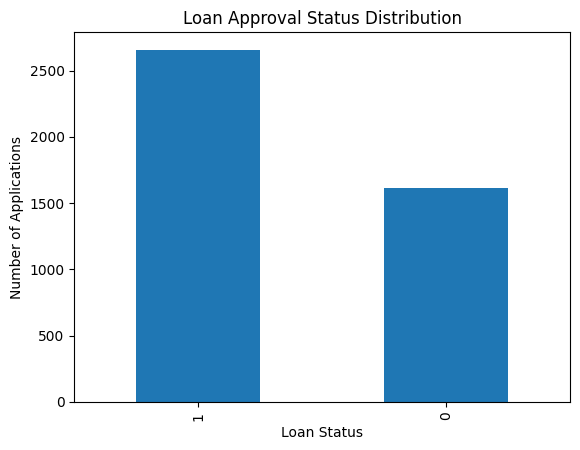

In [109]:
#Visualize Loan Status

# Matplotlib is used for creating visualizations.
import matplotlib.pyplot as plt

# Count the number of approved and rejected applications.
loan_counts = df['loan_status'].value_counts()

# Create a bar chart to compare the two classes.
loan_counts.plot(kind='bar')

# Add a title to explain what the chart represents.
plt.title('Loan Approval Status Distribution')

# Label the x-axis.
plt.xlabel('Loan Status')

# Label the y-axis.
plt.ylabel('Number of Applications')

# Display the chart.
plt.show()

In [110]:
#CIBIL Score vs Loan Status
df.groupby('loan_status')['cibil_score'].mean() # Compare the average CIBIL score for approved and rejected loan applications.



,cibil_score
loan_status,
0,429.468072
1,703.461973


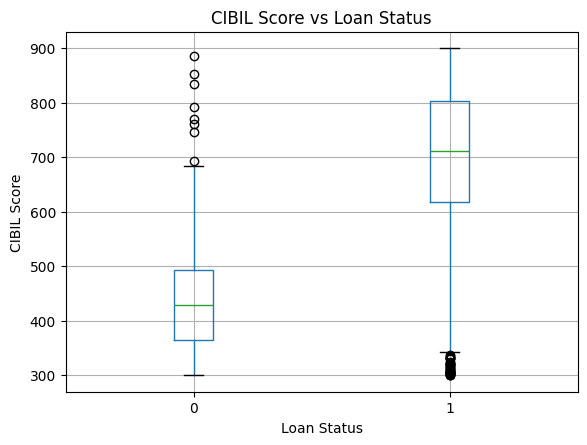

In [111]:
# Create a box plot to compare CIBIL score distributions
# between approved and rejected applications.

df.boxplot(column='cibil_score', by='loan_status')

# Add a title to the graph.
plt.title('CIBIL Score vs Loan Status')

# Remove the automatic pandas subtitle.
plt.suptitle('')

# Label the x-axis.
plt.xlabel('Loan Status')

# Label the y-axis.
plt.ylabel('CIBIL Score')

# Display the graph.
plt.show()

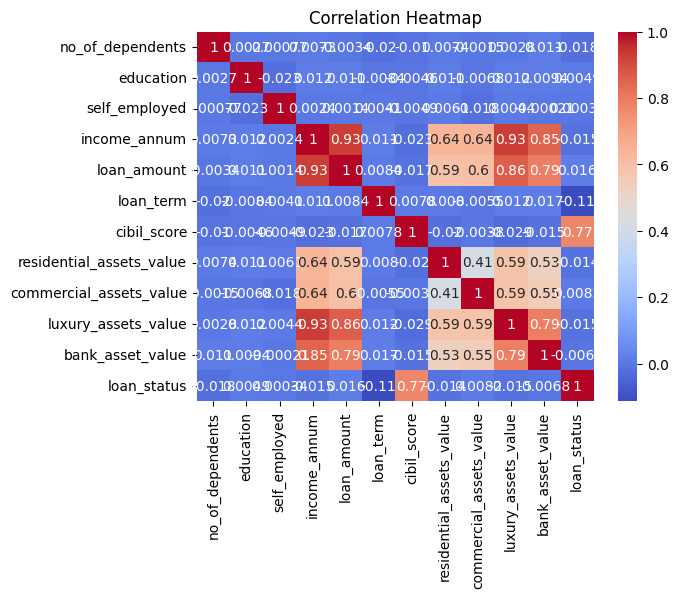

In [112]:
# corr() calculates the correlation between numerical columns.
# Correlation values range from -1 to +1.
# A value close to +1 means a strong positive relationship,
# while a value close to -1 means a strong negative relationship.

correlation = df.corr(numeric_only=True)

# Display the correlation matrix.
correlation

#heat map
# Seaborn provides advanced statistical visualizations.
import seaborn as sns

# Create a heatmap of the correlation matrix.
# annot=True displays the correlation values inside the cells.
sns.heatmap(correlation, annot=True, cmap='coolwarm')

# Add a title to the heatmap.
plt.title('Correlation Heatmap')

# Display the heatmap.
plt.show()

#5: Separate Features and Target

In [113]:

#  remove loan_status because it is the target  want to predict.
X = df.drop('loan_status', axis=1)

# y contains the target variable (loan approval status).
y = df['loan_status']

# Check the shape of X and y.
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4269, 11)
Target shape: (4269,)


#6: Train-Test Split

In [114]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets.
# 80% data will be used to train the Decision Tree.
# 20% data will be used to test how well it performs on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Check the sizes of training and testing data.
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 11)
Testing data: (854, 11)


#7: Create Decision Tree Classifier

In [115]:
from sklearn.tree import DecisionTreeClassifier


# This model will learn patterns from the training data
# and use them to predict whether a loan is Approved or Rejected.
model = DecisionTreeClassifier(
    random_state=42
)

# Display the model
model

DecisionTreeClassifier(random_state=42)

Why DecisionTreeClassifier?

Because our target (loan_status) has two categories:

1 → Approved
0 → Rejected

So this is a classification problem, and we use DecisionTreeClassifier.

Why random_state=42?

It makes the model's result reproducible, so you get consistent results when you run the notebook again.

#8. Train the model

In [116]:
# train the model
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#9: Prediction

In [117]:
y_pred = model.predict(X_test)

# Display the first 10 predictions.
y_pred[:10]

'''X_test → unseen applicant information
model.predict(X_test) → Decision Tree makes predictions
y_pred → stores those predicted results'''

array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0])

In [131]:
# New loan applicant data
new_loan = pd.DataFrame([[
    2, 1, 0, 5000000, 15000000, 15,
    750, 10000000, 5000000, 3000000, 4000000
]], columns=X.columns)

# Predict loan status
prediction = model.predict(new_loan)
print("Prediction:", prediction)

'''0 → Rejected
1 → Approved'''

Prediction: [1]


'0 → Rejected\n1 → Approved'

#10 Model Evaluation

In [118]:
from sklearn.metrics import accuracy_score

# Compare actual loan status with predicted loan status.
# Accuracy tells us the percentage of correct predictions.
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
#print("Accuracy (%):", accuracy * 100)

Accuracy: 0.977751756440281


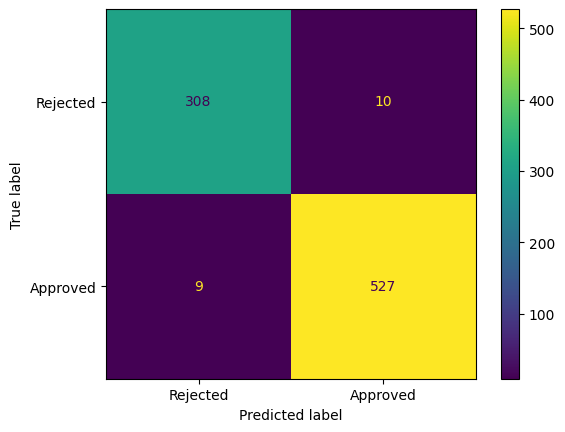

In [119]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create a confusion matrix using actual and predicted values.
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix with meaningful class names.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rejected', 'Approved']
)

disp.plot()


'''Why? Accuracy doesn't tell us which type of prediction was wrong. The confusion matrix does.'''

In [120]:
# Precision, Recall & F1-score

from sklearn.metrics import classification_report

# Generate precision, recall and F1-score
# for both loan classes.
print(classification_report(
    y_test,
    y_pred,
    target_names=['Rejected', 'Approved']
))

''' Precision → How many predicted approvals/rejections were actually correct?
Recall → How many actual approvals/rejections did the model correctly identify?
F1-score → Balance between precision and recall.  '''

              precision    recall  f1-score   support

    Rejected       0.97      0.97      0.97       318
    Approved       0.98      0.98      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



' Precision → How many predicted approvals/rejections were actually correct?\nRecall → How many actual approvals/rejections did the model correctly identify?\nF1-score → Balance between precision and recall.  '

#11: Decision Tree Visualization

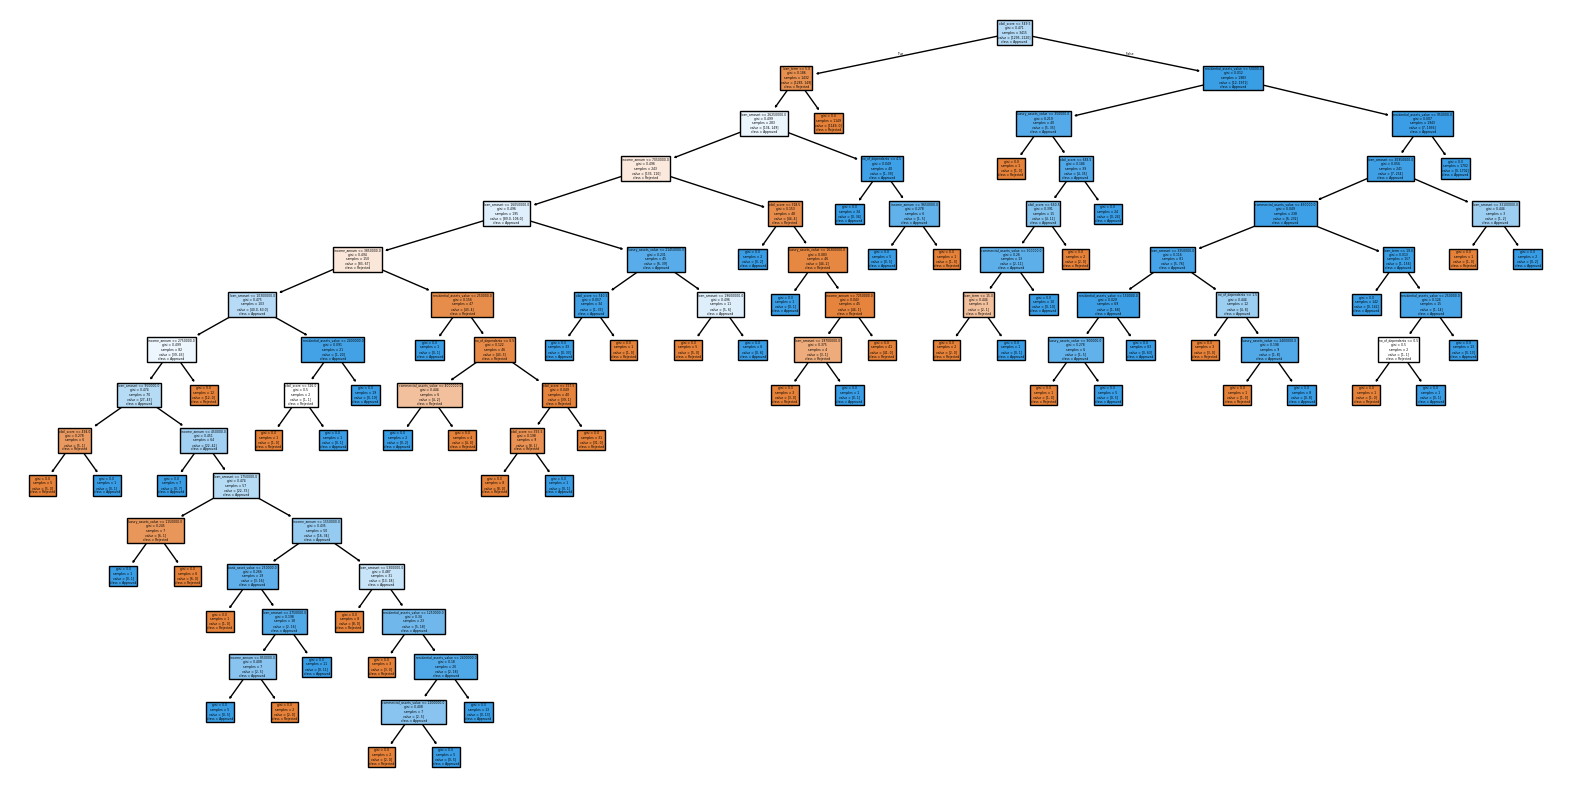

In [121]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create a large figure so that the complete tree is easier to read.
plt.figure(figsize=(20, 10))

# Plot the trained Decision Tree.
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    filled=True
)

# Display the tree.
plt.show()

#12 — Feature Importance

cibil_score                 0.827728
loan_term                   0.079202
loan_amount                 0.038654
income_annum                0.031342
luxury_assets_value         0.007217
residential_assets_value    0.006385
commercial_assets_value     0.004915
no_of_dependents            0.003627
bank_asset_value            0.000931
self_employed               0.000000
education                   0.000000
dtype: float64


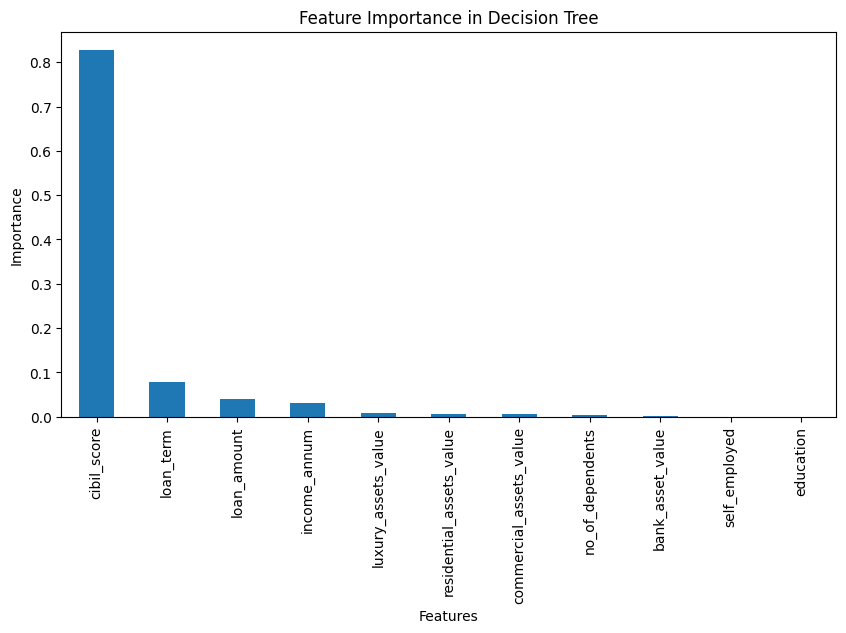

' This is useful because it tells us which features the Decision Tree considered most important while deciding whether a loan should be Approved or Rejected.'

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

# feature_importances_ tells us how important each feature
# was in making decisions inside the Decision Tree.
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Display the importance of every feature.
print(feature_importance)

# Create a bar chart to visualize feature importance.
feature_importance.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Feature Importance in Decision Tree')
plt.xlabel('Features')
plt.ylabel('Importance')

# Display the chart.
plt.show()


''' This is useful because it tells us which features the Decision Tree considered most important while deciding whether a loan should be Approved or Rejected.'''

cibil_score appears at the top, it means the tree found CIBIL score highly useful for separating Approved and Rejected loans.

“According to the feature importance analysis, CIBIL score is the most influential feature for predicting loan approval in our Decision Tree model. Loan term, loan amount, and income also contribute, but their impact is much smaller.”

#13 — Pruning the Decision Tree

What is pruning?

Our current Decision Tree is unpruned. It can keep creating branches until it fits the training data very closely.

Pruning means cutting unnecessary branches so that the tree becomes simpler and is less likely to overfit.

We will not randomly choose a depth. First, let's check how complex our current tree is.

In [123]:
# Check how depths our Decision Tree.


print("Tree Depth:", model.get_depth())

# Check the total number of decision nodes and leaf nodes.

print("Number of Leaves:", model.get_n_leaves())

Tree Depth: 16
Number of Leaves: 56


In [124]:
from sklearn.tree import DecisionTreeClassifier

# Create a new Decision Tree with a maximum depth of 5.

pruned_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the pruned Decision Tree using the same training data.
pruned_model.fit(X_train, y_train)

# Predict loan status using the pruned model.
pruned_pred = pruned_model.predict(X_test)

print("Pruned Tree Depth:", pruned_model.get_depth())
print("Pruned Tree Leaves:", pruned_model.get_n_leaves())

Pruned Tree Depth: 5
Pruned Tree Leaves: 17


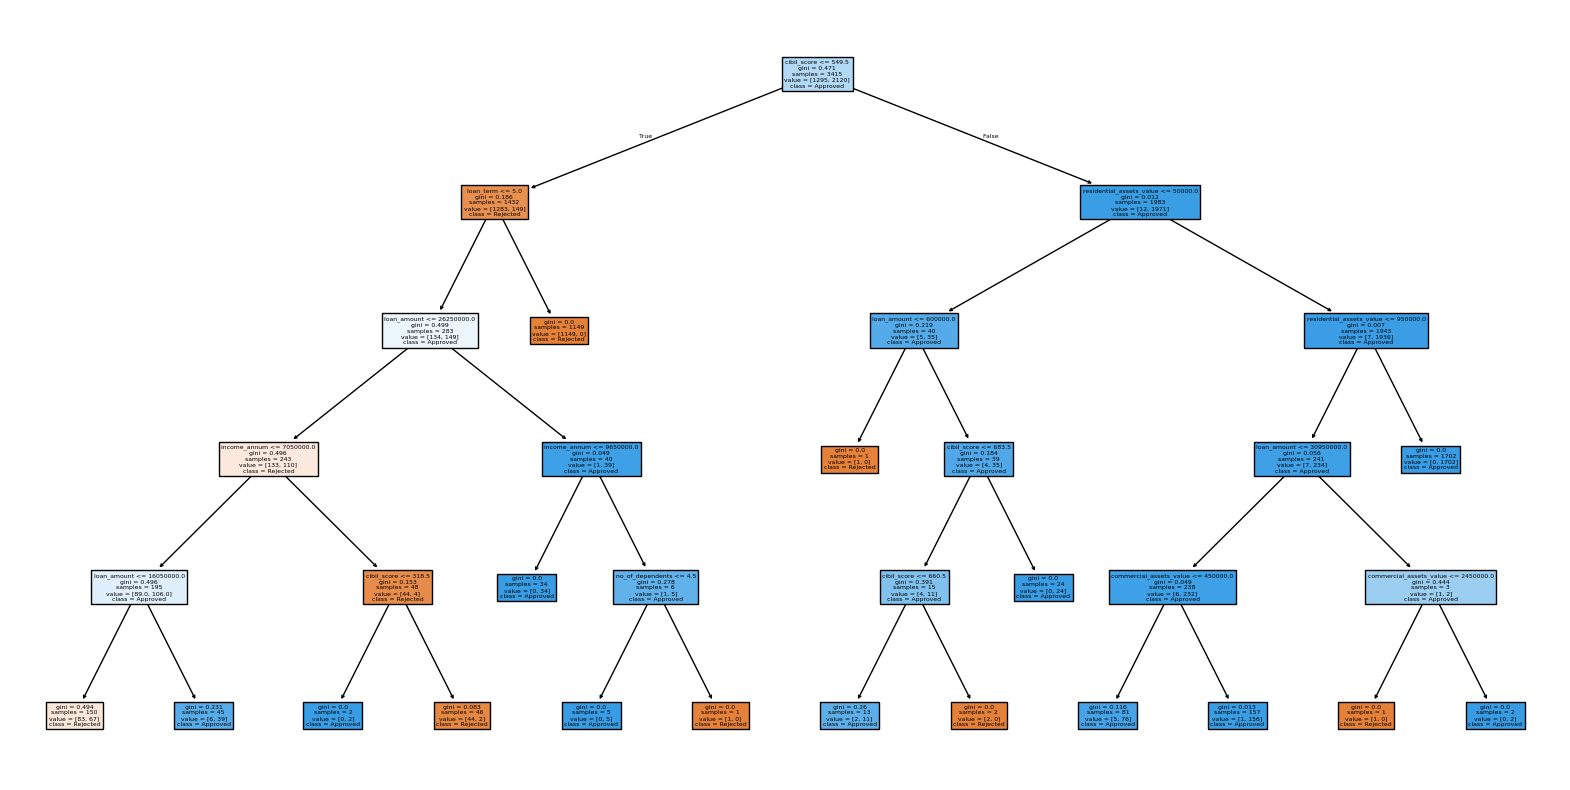

In [127]:
plt.figure(figsize=(20, 10))

# Plot the trained Decision Tree.
plot_tree(
    pruned_model,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    filled=True
)

# Display the tree.
plt.show()

#14 — Compare Accuracy

In [128]:
from sklearn.metrics import accuracy_score

# Calculate accuracy of the original (unpruned) Decision Tree.
original_accuracy = accuracy_score(y_test, y_pred)

# Calculate accuracy of the pruned Decision Tree.
pruned_accuracy = accuracy_score(y_test, pruned_pred)

# Display both accuracies for comparison.
print("Original Tree Accuracy:", original_accuracy)
print("Pruned Tree Accuracy:", pruned_accuracy)

print("\nOriginal Tree Accuracy (%):", original_accuracy * 100)
print("Pruned Tree Accuracy (%):", pruned_accuracy * 100)

Original Tree Accuracy: 0.977751756440281
Pruned Tree Accuracy: 0.968384074941452

Original Tree Accuracy (%): 97.7751756440281
Pruned Tree Accuracy (%): 96.8384074941452


# 15. Conclusion

In this project,  used a Decision Tree to predict whether a loan would be Approved or Rejected.

First, cleaned and prepared the data and then trained the Decision Tree model.

The original model gave **97.78% accuracy** on the test data.

From feature importance,  found that **CIBIL score was the most important feature** for loan approval prediction.

 also used pruning to make the tree simpler. The original tree had **16 levels and 56 leaves**, while the pruned tree had **5 levels and 17 leaves**.

The pruned model gave **96.84% accuracy**. So, pruning made the tree simpler, but the accuracy decreased slightly.

Overall, the Decision Tree performed well for this loan approval prediction problem.